> [!NOTE] ELI5
> Computational graph là bản đồ "ai sinh ra ai". Ví dụ: $y = 2x^\top x$. Bản đồ ghi: $x$ → nhân dot với $x$ → nhân 2 → $y$. Khi backward, đi ngược bản đồ này, áp dụng chain rule từng bước.


### Autograd giải quyết thế nào?

1. **Forward pass:** Mỗi phép tính được ghi vào **computational graph** — cây tính toán theo dõi từng value phụ thuộc vào value nào
2. **Backward pass (`backward()`):** Đi ngược graph, áp dụng **chain rule** tự động ở mỗi node
3. **Kết quả:** Gradient của mọi leaf tensor có `requires_grad=True`


In [4]:
import torch

x = torch.arange(4.0, requires_grad=True)
print(x)
print(torch.dot(x, x))
y = 2 * torch.dot(x, x)

y.backward()

print(x.grad)

print(x.grad == 4 * x)

tensor([0., 1., 2., 3.], requires_grad=True)
tensor(14., grad_fn=<DotBackward0>)
tensor([ 0.,  4.,  8., 12.])
tensor([True, True, True, True])


Ở trên là với output dạng scalar.

Còn đối với dạng vector thì ở dưới:


$$\mathbf{J} = \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \in \mathbb{R}^{m \times n}$$


Khi hàm số biến một vector thành một vector khác, đạo hàm của nó phình to ra thành một ma trận gọi là Jacobian Matrix.

- Nếu y có độ dài m và x có độ dài n, thì ma trận Jacobian J sẽ có kích thước m×n.

- Nó chứa tất cả các đạo hàm riêng của từng phần tử trong y đối với từng phần tử trong x.

Trong DL -> chỉ cần tính tổng gradient theo từng batch. không cần tính tất cả qua $J$:


In [ ]:
x.grad.zero_() # reset gradient to zero

y = x * x
print(y)

y.backward(torch.ones(len(x)))
print(x.grad)

tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)
tensor([0., 2., 4., 6.])


Giải thích:

3. Cách PyTorch xử lý (Jacobian-Vector Product)

Tính toán toàn bộ ma trận Jacobian rất tốn bộ nhớ và thời gian. Thực tế, trong Deep Learning, ta thường chỉ cần tổng hợp gradient qua các batch, nên ta không cần toàn bộ ma trận Jacobian đó.

Thay vào đó, PyTorch dùng một mẹo:

- Nó yêu cầu cậu phải truyền vào một vector v (thông qua tham số gradient) khi gọi backward().
- PyTorch sẽ tính phép nhân v⊤J thay vì tính toàn bộ J.

4. Giải mã đoạn code & Kết quả Toán học

Hãy nhìn vào đoạn code trong ảnh:

- y = x \* x: Ở đây y là một vector chứa các bình phương [x02​,x12​,x22​,x32​].

- y.backward(gradient=torch.ones(len(y))): Cậu đang truyền vào một vector toàn số 1: v=[1,1,1,1].

- Bản chất: Khi vector v toàn là số 1 (v=1), kết quả toán học trả về sẽ chính xác là gradient của tổng các phần tử ∑yi​ theo x.

- Nói cách khác, việc truyền torch.ones vào y.backward() cho kết quả y hệt như việc cậu tính tổng y trước rồi mới backward: y.sum().backward().

- Vì y=x2, nên đạo hàm của tổng x2 chính là 2x. Do đó kết quả in ra là tensor([0., 2., 4., 6.]).


## 5. Detaching computation

~ Kĩ thuật `ngắt luồng gradient`. Chức năng chính là cắt nhánh trong computational graph -> gradient descent không chạy qua nhánh đó nữa 

### Bản chất:
- Biến một tensor chứa cả một lịch sử tính toán thành hằng số

>[!Note] ELI5:
Bình thường, nếu món ăn bị phàn nàn, quản lý sẽ truy trách nhiệm ngược từ Robot trang trí $\rightarrow$ Robot nấu chính $\rightarrow$ Robot sơ chế.

>Nhưng nếu cậu áp dụng detach() vào bước Robot nấu chính, điều đó giống như việc quản lý ký giấy xác nhận món ăn đó là đồ hộp mua ngoài siêu thị (hằng số). Khi có lỗi xảy ra, quản lý chỉ mắng con Robot trang trí, và luồng truy cứu trách nhiệm dừng lại ngay tại đó, không ai quan tâm đồ hộp đó được làm ra thế nào nữa!



- **Ví dụ:** Tính $z = x \cdot y$ với $y = x^2$

In [9]:
x.grad.zero_()
y = x * x           # y = x²
u = y.detach()      # u = same value as y, nhưng bị cắt khỏi graph

z = u * x           # z = u * x (u treated as constant)
z.sum().backward()

print(x.grad)       # = u = x², KHÔNG phải 3x² như khi không detach
print(x.grad == u)  # True

tensor([0., 1., 4., 9.])
tensor([True, True, True, True])


| Cách         | `z = x * y * (...) = x * x * x`     | Gradient               |
| ------------ | ----------------------------------- | ---------------------- |
| Không detach | $z = x^3$                           | $\nabla_x z = 3x^2$    |
| Detach $y$   | $z = u \cdot x$, $u = \text{const}$ | $\nabla_x z = u = x^2$ |

#### Tại sao lại cần trò "ăn gian" này? (Ứng dụng thực tế)
Cậu có thể thắc mắc: "Tại sao phải cố tình làm sai lệch đạo hàm như vậy?" Thực ra, đây là một thủ thuật cực kỳ quyền lực:

Reinforcement Learning (RL - Học tăng cường): Trong các thuật toán như DQN, AI có một "mạng dự đoán" và một "mạng mục tiêu" (Target Network). Khi cập nhật, mạng dự đoán phải bám theo mạng mục tiêu. Nếu cậu không detach mạng mục tiêu, mỗi bước học, cả mục tiêu cũng tự động dịch chuyển theo, làm cho AI giống như con chó tự đuổi theo cái đuôi của mình vậy! Trạng thái sẽ bị sụp đổ.

Self-Supervised Learning (SSL): Trong các mô hình như SimSiam hay BYOL, hai nhánh mạng nơ-ron cùng học từ một ảnh. Nhờ có thủ thuật chặn gradient ở một nhánh (stop-gradient), mô hình mới không rơi vào trạng thái "lười biếng" (tự đưa tất cả output về 0 để hàm loss bằng 0).

## 6. Gradient qua python control flow

Ngày xưa, việc dùng if/else hay while trong mạng Neural là một cơn ác mộng. Nhưng với PyTorch, cậu cứ dùng code Python thuần túy một cách tự nhiên!Tại sao nó lại hoạt động được (Dynamic Graph)?

Hãy tưởng tượng PyTorch là một người quay phim chạy theo cậu (gọi là cơ chế Tape-based Autograd):
- Cậu chạy code đến đâu, nó "ghi hình" (record) các phép toán lại đến đó.
- Nếu vòng lặp while chạy 5 lần, PyTorch sẽ ghi vào đồ thị 5 phép nhân liên tiếp: $b \rightarrow *2 \rightarrow *2 \rightarrow *2 \rightarrow *2 \rightarrow *2$.
- Nếu điều kiện if đúng, nó chỉ ghi nhánh if. Nó hoàn toàn ngó lơ nhánh else.

Vì đồ thị được xây dựng động (dynamically) ngay trong lúc chạy, nên dù đường đi của dữ liệu có lắt léo cỡ nào, lúc gọi d.backward(), PyTorch chỉ việc "tua ngược" lại đúng đoạn băng nó vừa ghi hình để tính đạo hàm. Cực kỳ thông minh phải không? ♪

## 7. 4 Quy tắc vàng:

1. Gắn cờ theo dõi (Attach gradient): Bật công tắc requires_grad=True cho những tham số cậu muốn model học (như trọng số $W$, bias $b$).
2. Ghi hình (Record computation): Viết code tính toán hàm loss một cách bình thường (Forward pass). PyTorch đang âm thầm vẽ đồ thị ở background.
3. Phát lệnh truyền ngược (Execute backprop): Hô to loss.backward()! Lúc này đồ thị bắt đầu chạy ngược từ Loss về Input.
4. Thu hoạch (Access gradient): Lấy kết quả đạo hàm ở thuộc tính .grad (ví dụ x.grad) để đem đi tối ưu hóa (như dùng SGD hay Adam).

## 9. Kết nối với Backpropagation

Autograd là **cài đặt kỹ thuật** của backpropagation:

- **Backprop (lý thuyết):** Áp dụng chain rule ngược qua layers
- **Autograd (thực hành):** Tự động áp dụng chain rule trên computational graph

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y_n} \cdot \frac{\partial y_n}{\partial y_{n-1}} \cdots \frac{\partial y_1}{\partial x} = \prod_{i} \mathbf{J}_i$$

Mỗi `backward()` call = một lần traverse toàn bộ cây này từ output về input.

---

## Ex.
1. Tại sao second derivative ($f''$) đắt hơn nhiều so với first derivative?
2. Sau `backward()`, gọi lại ngay lần nữa — điều gì xảy ra? (Hint: PyTorch xóa graph sau backward mặc định)
3. Trong ví dụ control flow, nếu `a` là vector thay vì scalar, điều gì xảy ra?
4. Vẽ $f(x) = \sin(x)$ và $f'(x)$ **chỉ dùng autograd**, không hardcode $\cos(x)$.

1. Sự khác biệt nằm ở sự bùng nổ của không gian ma trận (Curse of Dimensionality):
- Về không gian lưu trữ (Memory): Đạo hàm bậc 1 của một mạng nơ-ron có $N$ tham số chỉ là một vector Gradient có chiều dài $N$. Nhưng đạo hàm bậc 2 (Ma trận Hessian) lại lưu lại sự tương tác chéo giữa mọi cặp tham số với nhau, nên nó có kích thước $N \times N$. Nếu model có 1 triệu tham số, ma trận Hessian sẽ chứa $10^{12}$ con số, đủ để làm nổ tung mọi loại VRAM ngay lập tức!
- Về chi phí tính toán (Compute): Để tính $f''$, PyTorch phải bật chế độ create_graph=True trong lần backward đầu tiên để lưu lại toàn bộ đồ thị tính toán của chính quá trình đạo hàm đó, sau đó lại chạy backward thêm một lần nữa trên cái đồ thị khổng lồ này. Chi phí tính toán là vô cùng đắt đỏ.

2.
LỖI RuntimeError! * Đồ thị tính toán (Computational Graph) trong PyTorch được thiết kế theo kiểu "dùng một lần rồi vứt".

Ngay khi lệnh backward() đầu tiên chạy xong, PyTorch sẽ tự động giải phóng toàn bộ bộ nhớ chứa đồ thị đó để tiết kiệm tài nguyên.

Nếu cậu gọi backward() lần hai, hệ thống không còn bản đồ nào để dò ngược nữa nên sẽ báo lỗi.

Giải pháp: Nếu cậu thật sự muốn gọi nhiều lần (ví dụ như trong mạng GANs), cậu phải báo trước cho PyTorch bằng cách ghi rõ: loss.backward(retain_graph=True).

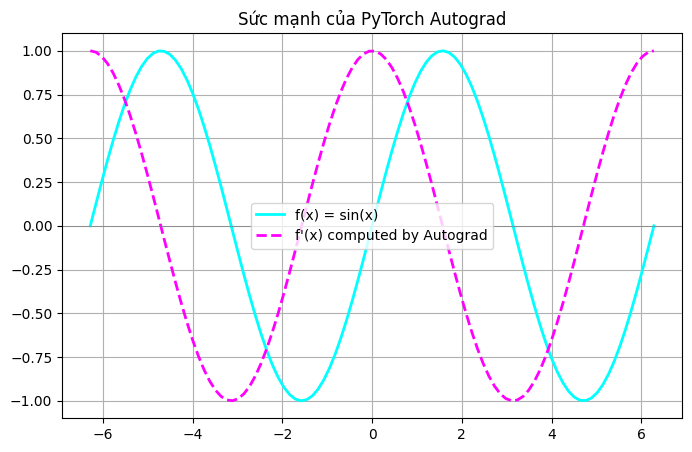

In [10]:
import torch
import matplotlib.pyplot as plt

# 1. Tạo tensor x từ -2π đến 2π (bật requires_grad=True để theo dõi)
x = torch.linspace(-2 * torch.pi, 2 * torch.pi, 100, requires_grad=True)

# 2. Tính f(x) = sin(x)
y = torch.sin(x)

# 3. Tính đạo hàm f'(x) bằng Autograd
# Vì y là vector, ta phải truyền vào vector v toàn số 1 (Jacobian-Vector product)
y.backward(torch.ones_like(y))

# Lấy đạo hàm từ thuộc tính grad của x
y_phay = x.grad

# 4. Vẽ đồ thị
# Cần dùng .detach() để tách các tensor ra khỏi đồ thị tính toán trước khi vẽ
plt.figure(figsize=(8, 5))
plt.plot(x.detach().numpy(), y.detach().numpy(), label="f(x) = sin(x)", color="cyan", linewidth=2)
plt.plot(x.detach().numpy(), y_phay.numpy(), label="f'(x) computed by Autograd", color="magenta", linestyle="--", linewidth=2)

plt.axhline(0, color='gray', linewidth=0.5)
plt.title("Sức mạnh của PyTorch Autograd")
plt.legend()
plt.grid(True)
plt.show()